In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler    
import seaborn as sns
from tmdbv3api import TMDb, Movie
from tqdm import tqdm
import plotly.express as px

In [21]:
df_links = pd.read_csv('links.csv')
df_movies = pd.read_csv('movies.csv')
df_ratings = pd.read_csv('ratings.csv')
df_tags = pd.read_csv('tags.csv')
len(df_ratings)


100836

In [ ]:
print(len(df_links))
len(df_movies)

9742

In [ ]:
def head(df):
    return df.head()

def isnull(df):
    return df.sum().isnull()

print(head(df_links))
print(head(df_movies))
print(head(df_ratings))
head(df_tags)

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [25]:
print(isnull(df_links))
print(isnull(df_movies))
print(isnull(df_ratings))
print(isnull(df_tags))

movieId    False
imdbId     False
tmdbId     False
dtype: bool
movieId    False
title      False
genres     False
dtype: bool
userId       False
movieId      False
rating       False
timestamp    False
dtype: bool
userId       False
movieId      False
tag          False
timestamp    False
dtype: bool


In [26]:
pip install tmdbv3api

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
tmdb = TMDb()
tmdb.api_key = '7638ae832eab6400fbb78b923429bcb8'
tmdb.language = 'fr'
movie_api = Movie()
enriched_data = []

first_valid_row = df_links.dropna(subset=['tmdbId']).iloc[0]
tmdb_id = int(first_valid_row['tmdbId'])
m = movie_api.details(int(tmdb_id))
print(m.__dict__.keys())

dict_keys(['_json', '_key', '_dict_key', '_dict_key_name', '_obj_list', '_list_only', 'adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'origin_country', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'videos', 'trailers', 'images', 'casts', 'translations', 'keywords', 'release_dates'])


on enrichit les données avec l'API TMDb pour avoir du contexte. 'links.csv' contient seulement les caractéristiques 'movieId','imdbId','tmdbId'

In [28]:
""""
for index, row in tqdm(df_links.iterrows(), total = df_links.shape[0]):
    tmdb_id = row['tmdbId']
    
    if pd.isna(tmdb_id):
        enriched_data.append({})
        continue
    
    try:
        m = movie_api.details(int(tmdb_id))
        enriched_data.append({
            'movieId': row['movieId'], 
            'budget': getattr(m, 'budget', 0),
            'revenue': getattr(m, 'revenue', 0),
            'runtime': getattr(m, 'runtime', 0),
            'release_date': getattr(m, 'release_date', np.nan),
            'vote_average_tmdb': getattr(m, 'vote_average', 0),
            'vote_count_tmdb': getattr(m, 'vote_count', 0)
        })
        
    except Exception as e:
        enriched_data.append({'movieId': row['movieId']})
        
df_enriched = pd.DataFrame(enriched_data)
df_enriched.to_csv('movies_enriched.csv', index = False)
df_meta = pd.read_csv('movies_enriched.csv')
"""

'"\nfor index, row in tqdm(df_links.iterrows(), total = df_links.shape[0]):\n    tmdb_id = row[\'tmdbId\']\n    \n    if pd.isna(tmdb_id):\n        enriched_data.append({})\n        continue\n    \n    try:\n        m = movie_api.details(int(tmdb_id))\n        enriched_data.append({\n            \'movieId\': row[\'movieId\'], \n            \'budget\': getattr(m, \'budget\', 0),\n            \'revenue\': getattr(m, \'revenue\', 0),\n            \'runtime\': getattr(m, \'runtime\', 0),\n            \'release_date\': getattr(m, \'release_date\', np.nan),\n            \'vote_average_tmdb\': getattr(m, \'vote_average\', 0),\n            \'vote_count_tmdb\': getattr(m, \'vote_count\', 0)\n        })\n        \n    except Exception as e:\n        enriched_data.append({\'movieId\': row[\'movieId\']})\n        \ndf_enriched = pd.DataFrame(enriched_data)\ndf_enriched.to_csv(\'movies_enriched.csv\', index = False)\ndf_meta = pd.read_csv(\'movies_enriched.csv\')\n'

In [29]:
df_meta = pd.read_csv('movies_enriched.csv')
df_meta.columns


Index(['movieId', 'budget', 'revenue', 'runtime', 'release_date',
       'vote_average_tmdb', 'vote_count_tmdb'],
      dtype='str')

In [30]:
df_ratings_sumup = df_ratings.groupby('movieId').agg({'rating' : ['mean', 'count', 'std']})
df_ratings_sumup = df_ratings_sumup.reset_index()
df_ratings_sumup.columns = ['movieId', 'mean_rating', 'num_votes', 'std_rating']


In [31]:
df_ratings_sumup.head()

,movieId,mean_rating,num_votes,std_rating
0,1,3.920930,215,0.834859
1,2,3.431818,110,0.881713
2,3,3.259615,52,1.054823
3,4,2.357143,7,0.852168
4,5,3.071429,49,0.907148


In [32]:
len(df_ratings_sumup)

9724

In [33]:
df_tags['tag'] = df_tags['tag'].astype(str)
df_tags_sumup = df_tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
df_tags_sumup.columns = ['movieId', 'all_tags']

In [34]:
df_final = df_movies.merge(df_meta, on = 'movieId', how = 'left')
df_final = df_final.merge(df_ratings_sumup, on = 'movieId', how = 'left')
df_final = df_final.merge(df_tags_sumup,on = 'movieId', how = 'left')
print(df_final.columns)
print(df_final.head())
print(len(df_final))

Index(['movieId', 'title', 'genres', 'budget', 'revenue', 'runtime',
       'release_date', 'vote_average_tmdb', 'vote_count_tmdb', 'mean_rating',
       'num_votes', 'std_rating', 'all_tags'],
      dtype='str')
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres      budget      revenue  \
0  Adventure|Animation|Children|Comedy|Fantasy  30000000.0  401157969.0   
1                   Adventure|Children|Fantasy  65000000.0  262821940.0   
2                               Comedy|Romance  25000000.0   71500000.0   
3                         Comedy|Drama|Romance  16000000.0   81452156.0   
4                                       Comedy         0.0   76594107.0   

   runtime release_date  vote_avera

In [35]:
df_final.to_csv('df_final.csv', index = True)

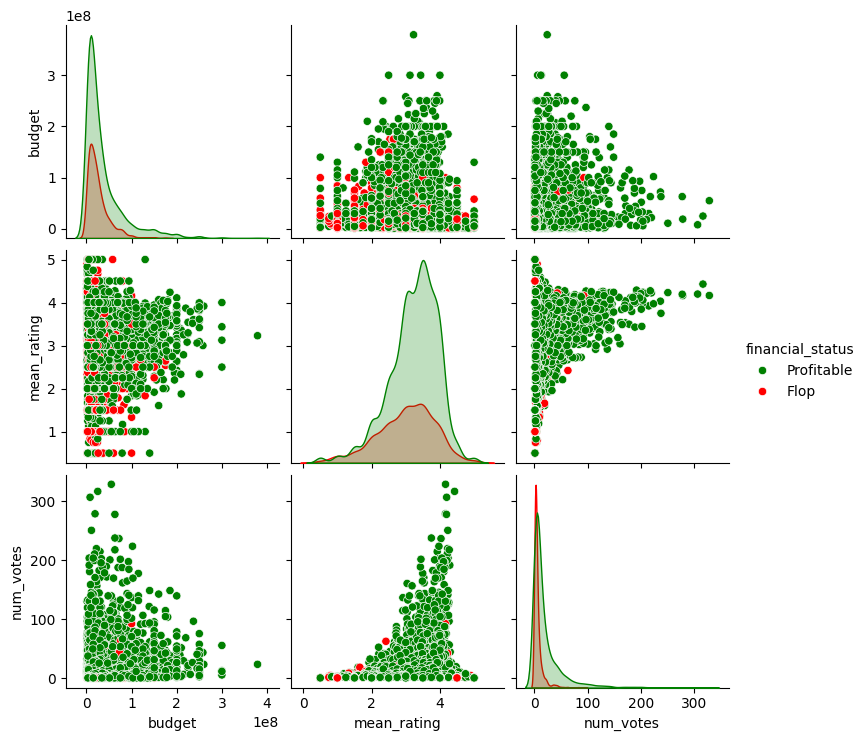

In [36]:
df_roi = df_final[(df_final['budget'] > 1000000) & (df_final['revenue'] > 0)].copy()
df_roi['financial_status'] = df_roi.apply(lambda x: 'Profitable' if x['revenue'] > x['budget'] else 'Flop', axis=1)

sns.pairplot(df_roi, 
             vars=['budget', 'mean_rating', 'num_votes'], 
             hue='financial_status',
             palette={'Profitable': 'green', 'Flop': 'red'})
plt.show()

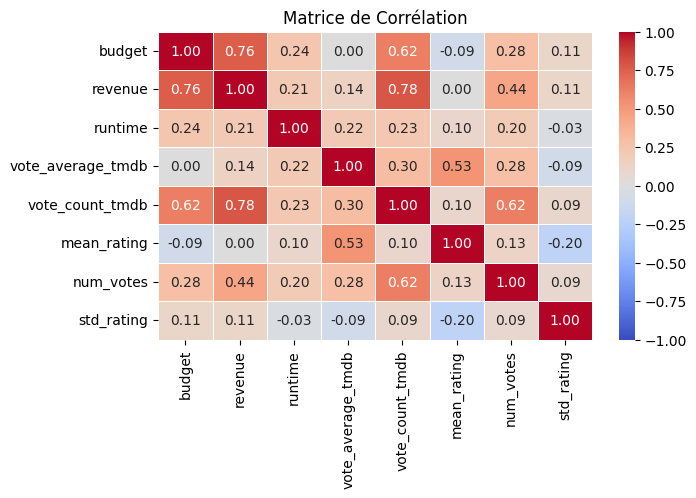

In [37]:
cols_to_corr = df_final.select_dtypes(include=['float64', 'int64']).drop(columns=['movieId'], errors='ignore')

plt.figure(figsize=(7, 4))

sns.heatmap(cols_to_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matrice de Corrélation')
plt.show()

T-SNE

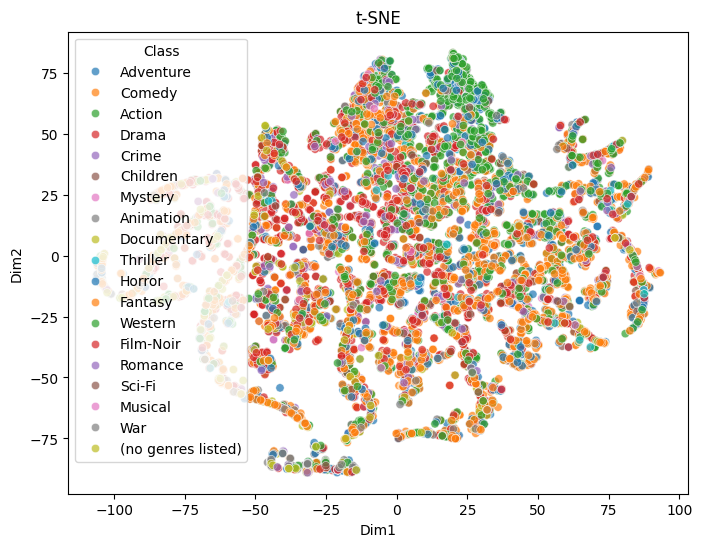

In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer

X_num = df_final[['budget', 'revenue', 'mean_rating', 'num_votes', 'runtime']].fillna(0).values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
tfidf = TfidfVectorizer(max_features=100, stop_words='english') 
X_text = tfidf.fit_transform(df_final['all_tags'].fillna(''))

X_combined = hstack([X_num_scaled, X_text])
tsne = TSNE(n_components=2, perplexity=30, init='random', learning_rate='auto')
X_embedded = tsne.fit_transform(X_combined)
df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
df_tsne['Class'] = df_final['genres'].str.split('|').str[0].values
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne,x='Dim1', y='Dim2', hue='Class', palette='tab10',alpha=0.7)
plt.title('t-SNE')
plt.show()

In [46]:
fig = px.scatter(df_tsne, x = 'Dim1', y= 'Dim2', color= 'Class')
fig.update_layout(
    title="T-SNE visualization",
    xaxis_title="Dimension 1",
    yaxis_title="Dimension 2",
)
fig.show()

PCA

In [52]:
pca = PCA(n_components = 2)
scaler = StandardScaler()
y = df_tsne['Class']
X_pca = pca.fit_transform(X_num_scaled)
fig_pca = px.scatter(x = X_pca[:,0], y =X_pca[:,1], color = y)
fig_pca.update_layout(
    title="PCA visualization of Custom Classification dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig_pca.show()


ISOMAP

In [53]:
embedding = Isomap(n_components = 2, n_neighbors= 30)
X_isomap = embedding.fit_transform(X_num_scaled)
fig_iso = px.scatter( x = X_isomap[:,0], y =X_isomap[:,1], color = y, opacity = 0.7, title = 'Isomap Projection')
fig_iso.show()

LocallyLinearEmbedding (LLE)

In [55]:
embedding = LocallyLinearEmbedding(n_components = 2)
X_transformed = embedding.fit_transform(X_num_scaled)
fig_lle = px.scatter( x = X_transformed[:,0], y =X_transformed[:,1], color = y, opacity = 0.7, title = 'LLE Projection')
fig_lle.show()